In [24]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx # we will use it for visualization
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.optimize import milp
from scipy import optimize
from scipy.sparse.csgraph import shortest_path

## Common parameters

Shared by both environments so they are defined exactly once.

In [25]:
# Problem parameters shared by the stationary and the non-stationary environment
n_campaigns = 3
n_users = 2000              # Number of rounds T
B = 300                     # Total budget
rho = B / n_users           # Budget per round

# Valuation of each campaign (same for both environments)
my_valuations = np.array([0.6, 0.7, 0.8])

# Discrete set of possible bids
available_bids = np.linspace(0, 1, 11)

t = np.arange(n_users)

print("Campaign valuations:", my_valuations)
print("Possible bids:", available_bids)
print("Budget per round:", rho)


Campaign valuations: [0.6 0.7 0.8]
Possible bids: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Budget per round: 0.15


## Stationary Environment (Requirement 2)

**What Requirement 2 has.** For campaign $i$ there are $k_i$ competitors, each bidding $U(0,1)$, so the highest competing bid is

$$
m_i(t) = \max_{j=1,\dots,k_i} u_{ij}(t), \qquad u_{ij}(t) \sim U(0,1) \;\Rightarrow\; m_i(t) \sim \text{Beta}(k_i, 1), \quad \Pr[b \ge m_i(t)] = b^{\,k_i}.
$$

The whole distribution is characterised by one integer $k_i$: more competitors pushes the max toward 1 and makes winning harder. That is the parameter to make time-varying.

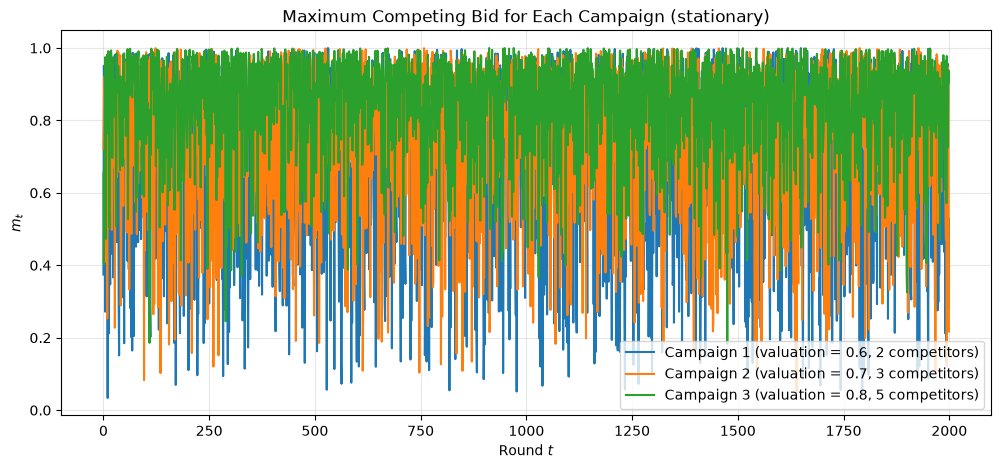

Number of competitors: [2, 3, 5]
Shape of m_t_stat: (3, 2000)


In [26]:
# Reproducibility
np.random.seed(42)

# Different (fixed) number of competitors for each campaign
n_competitors_stat = [2, 3, 5]

# Generate uniformly distributed bids for each campaign
other_bids_stat = [
    np.random.uniform(
        0,
        1,
        size=(n_competitors_stat[campaign], n_users)
    )
    for campaign in range(n_campaigns)
]

# Maximum competing bid for each campaign and round (stationary sequence)
m_t_stat = np.array([
    campaign_bids.max(axis=0)
    for campaign_bids in other_bids_stat
])

# Plot the maximum competing bid for each campaign
plt.figure(figsize=(12, 5))

for campaign in range(n_campaigns):
    plt.plot(
        m_t_stat[campaign],
        label=(
            f"Campaign {campaign + 1} "
            f"(valuation = {my_valuations[campaign]}, "
            f"{n_competitors_stat[campaign]} competitors)"
        )
    )

plt.title("Maximum Competing Bid for Each Campaign (stationary)")
plt.xlabel("Round $t$")
plt.ylabel("$m_t$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Number of competitors:", n_competitors_stat)
print("Shape of m_t_stat:", m_t_stat.shape)


## Non-stationary Environment (Requirement 3)

**Same generator, with $k_i(t)$ changing quickly.** Keep the uniform bidders, but let the number of competitors in campaign $i$ at round $t$ be a fixed, pre-specified sequence $k_i(t)$:

$$
m_i(t) = \max_{j=1,\dots,k_i(t)} u_{ij}(t), \qquad u_{ij}(t) \sim U(0,1), \qquad m_i(t) \sim \text{Beta}(k_i(t), 1).
$$

Then the win probability of bid $b$ is $b^{\,k_i(t)}$, which changes with $t$. The simplest way to make $k_i(t)$ "change quickly" is to cycle it through a short list every few rounds, i.e. a periodic schedule with a period much smaller than $T$:

$$
k_i(t) = \kappa_i\!\left[\, \left\lfloor \tfrac{t}{L_i} \right\rfloor \bmod |\kappa_i| \right], \qquad \kappa_1 = (1, 3),\; \kappa_2 = (1, 5, 3),\; \kappa_3 = (6, 1, 3),\; L = (10, 20, 30).
$$

So:
1. campaign 1 alternates between 1 and 3 competitors ($\kappa_1 = (1, 3)$) every $L_1 = 10$ rounds,
2. campaign 2 cycles through 1, 5, 3 competitors ($\kappa_2 = (1, 5, 3)$) every $L_2 = 20$ rounds,
3. campaign 3 cycles through 6, 1, 3 competitors ($\kappa_3 = (6, 1, 3)$) every $L_3 = 30$ rounds.

Each campaign uses a different list $\kappa_i$ and a different interval length $L_i$, so the campaigns are not synchronised. With $T = 2000$ and $L_i \le 30$ there are dozens of regime changes per campaign, which is what makes the environment *highly* non-stationary.

The values in $\kappa_i$ are chosen so that every campaign alternates between a regime where it is *worth bidding* ($k = 1$: the mean competing bid is $0.5 < v_i$ and the best bid wins 20-40% of the time) and a regime where it is *hard* ($k \ge 3$: the mean competing bid is above $v_i$ and the best bid wins less than 10% of the time). Hence both the optimal bid within a campaign and the optimal allocation of budget across campaigns change every $L_i$ rounds.

The sequence is generated once with a fixed seed and then treated as given (oblivious adversary): from the learner's point of view it is a fixed, non-stochastic sequence.


In [27]:
# Reproducibility: the sequence is generated ONCE and then treated as fixed
# (oblivious adversary) -> non-stochastic from the learner's point of view
np.random.seed(42)

# Non-stationary schedule of the number of competitors:
# campaign i cycles through kappa[i], switching every L[i] rounds
kappa = [
    [1, 3],        # campaign 1: "worth it" (k=1) vs "hard" (k=3)
    [1, 5, 3],     # campaign 2: worth it -> hard -> medium
    [6, 1, 3],     # campaign 3: hard -> worth it -> medium
]
L = [10, 20, 30]   # rounds per regime for each campaign

# k_i(t) = kappa_i[ floor(t / L_i) mod |kappa_i| ]
n_competitors_t = np.array([
    np.array(kappa[campaign])[(t // L[campaign]) % len(kappa[campaign])]
    for campaign in range(n_campaigns)
])                       # shape (n_campaigns, T)

# m_i(t) = max of k_i(t) uniform bids  ->  Beta(k_i(t), 1)
k_max = max(max(k) for k in kappa)
all_bids = np.random.uniform(0, 1, size=(n_campaigns, k_max, n_users))

m_t_nonstat = np.zeros((n_campaigns, n_users))
for campaign in range(n_campaigns):
    for round_t in range(n_users):
        k = n_competitors_t[campaign, round_t]
        m_t_nonstat[campaign, round_t] = all_bids[campaign, :k, round_t].max()

print("Schedules kappa:", kappa, "with interval lengths L:", L)
print("Shape of m_t_nonstat:", m_t_nonstat.shape)

# Expected utility of the best bid in each regime (justifies the choice of kappa)
print(f"\n{'camp':>4} {'v_i':>5} {'k':>3} {'E[m]':>6} {'best b':>7} {'P(win)':>7} {'utility':>8}")
for campaign in range(n_campaigns):
    v = my_valuations[campaign]
    for k in kappa[campaign]:
        utility = (v - available_bids) * available_bids ** k
        j = utility.argmax()
        print(f"{campaign + 1:>4} {v:>5.1f} {k:>3d} {k / (k + 1):>6.2f} "
              f"{available_bids[j]:>7.1f} {available_bids[j] ** k:>7.3f} {utility[j]:>8.4f}")


Schedules kappa: [[1, 3], [1, 5, 3], [6, 1, 3]] with interval lengths L: [10, 20, 30]
Shape of m_t_nonstat: (3, 2000)

camp   v_i   k   E[m]  best b  P(win)  utility
   1   0.6   1   0.50     0.3   0.300   0.0900
   1   0.6   3   0.75     0.4   0.064   0.0128
   2   0.7   1   0.50     0.3   0.300   0.1200
   2   0.7   5   0.83     0.6   0.078   0.0078
   2   0.7   3   0.75     0.5   0.125   0.0250
   3   0.8   6   0.86     0.7   0.118   0.0118
   3   0.8   1   0.50     0.4   0.400   0.1600
   3   0.8   3   0.75     0.6   0.216   0.0432


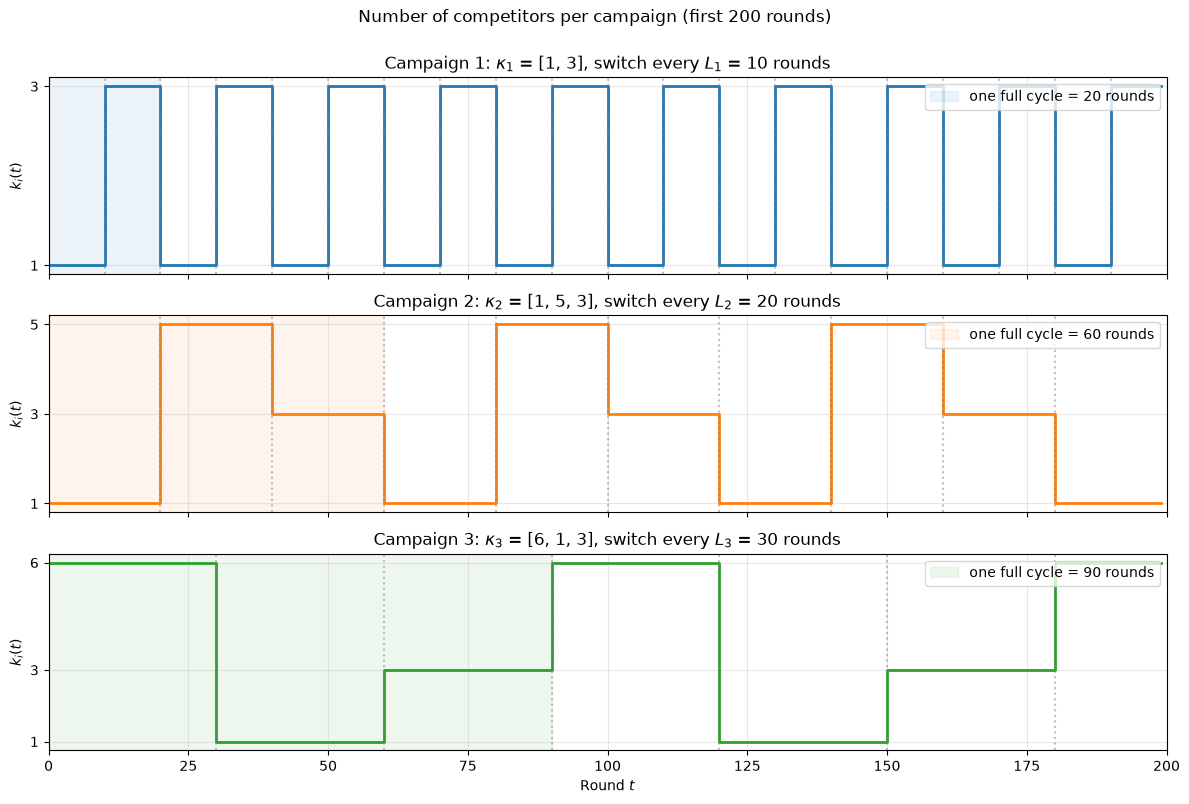

In [28]:
# ------------------------------------------------------------------
# Plot 1: k_i(t) per campaign (one subplot each) to show the cyclic behaviour
# ------------------------------------------------------------------
zoom = 200

fig, axes = plt.subplots(n_campaigns, 1, figsize=(12, 8), sharex=True)

for campaign in range(n_campaigns):
    ax = axes[campaign]
    ax.step(
        t[:zoom], n_competitors_t[campaign, :zoom],
        where="post", color=f"C{campaign}", linewidth=2
    )

    # vertical lines at every regime change
    for change in range(0, zoom, L[campaign]):
        ax.axvline(change, color="gray", linestyle=":", alpha=0.5)

    # shade one full cycle to highlight the period
    period = L[campaign] * len(kappa[campaign])
    ax.axvspan(
        0, period, color=f"C{campaign}", alpha=0.08,
        label=f"one full cycle = {period} rounds"
    )

    ax.set_yticks(sorted(set(kappa[campaign])))
    ax.set_ylabel("$k_i(t)$")
    ax.set_title(
        f"Campaign {campaign + 1}: $\\kappa_{campaign + 1}$ = {kappa[campaign]}, "
        f"switch every $L_{campaign + 1}$ = {L[campaign]} rounds"
    )
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Round $t$")
axes[-1].set_xlim(0, zoom)
plt.suptitle(f"Number of competitors per campaign (first {zoom} rounds)", y=1.0)
plt.tight_layout()
plt.show()

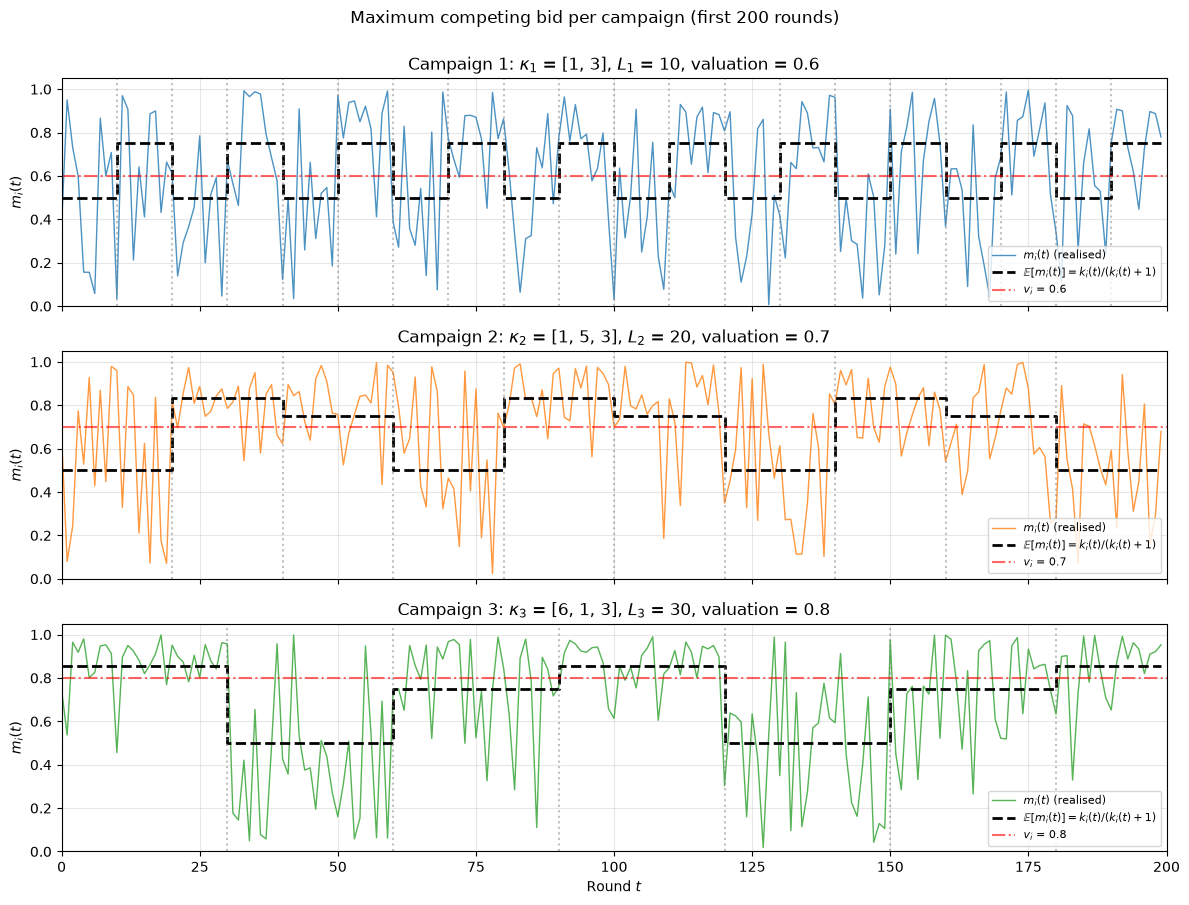

In [29]:
# ---- Plot: m_i(t) per campaign, one subplot each ----
zoom = 200

fig, axes = plt.subplots(n_campaigns, 1, figsize=(12, 9), sharex=True)

for campaign in range(n_campaigns):
    ax = axes[campaign]

    # realised highest competing bid
    ax.plot(
        t[:zoom], m_t_nonstat[campaign, :zoom],
        color=f"C{campaign}", linewidth=1, alpha=0.8,
        label="$m_i(t)$ (realised)"
    )

    # mean of Beta(k, 1) is k / (k + 1): shows the regime the sample comes from
    expected_m = n_competitors_t[campaign, :zoom] / (n_competitors_t[campaign, :zoom] + 1)
    ax.step(
        t[:zoom], expected_m, where="post",
        color="black", linewidth=2, linestyle="--",
        label="$\\mathbb{E}[m_i(t)] = k_i(t) / (k_i(t) + 1)$"
    )

    # vertical lines at every regime change
    for change in range(0, zoom, L[campaign]):
        ax.axvline(change, color="gray", linestyle=":", alpha=0.5)

    # my valuation, for reference
    ax.axhline(
        my_valuations[campaign], color="red", linestyle="-.", alpha=0.6,
        label=f"$v_i$ = {my_valuations[campaign]}"
    )

    ax.set_ylim(0, 1.05)
    ax.set_ylabel("$m_i(t)$")
    ax.set_title(
        f"Campaign {campaign + 1}: $\\kappa_{campaign + 1}$ = {kappa[campaign]}, "
        f"$L_{campaign + 1}$ = {L[campaign]}, valuation = {my_valuations[campaign]}"
    )
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Round $t$")
axes[-1].set_xlim(0, zoom)
plt.suptitle(f"Maximum competing bid per campaign (first {zoom} rounds)", y=1.0)
plt.tight_layout()
plt.show()

**Benchmark.** Since the environment is non-stochastic, the benchmark is the best fixed strategy in hindsight on the realised sequence $m(1), \dots, m(T)$, subject to the budget:

$$
\text{OPT} = \max_{b \in \mathcal{B}^N,\; S \in \mathcal{I}(G)} \sum_{t=1}^{T} \sum_{i \in S} (v_i - b_i)\,\mathbb{1}\{b_i \ge m_i(t)\}
\quad \text{s.t.} \quad \sum_{t=1}^{T} \sum_{i \in S} b_i\,\mathbb{1}\{b_i \ge m_i(t)\} \le B,
$$

and the regret is

$$
R_T = \text{OPT} - \sum_{t=1}^{T} \sum_{i \in S_t} (v_i - b_i(t))\,\mathbb{1}\{b_i(t) \ge m_i(t)\}.
$$

In [30]:
## Benchmark: best fixed strategy in hindsight (with budget and conflict graph)

from itertools import combinations, product
from collections import namedtuple
from scipy import optimize

# Conflict graph (same as Requirement 2): campaign 2 and 3 are mutually exclusive
conflict_edges = [(1, 2)]

ClairvoyantResult = namedtuple(
    "ClairvoyantResult",
    ["gamma", "super_arms", "super_arm_rewards", "super_arm_costs",
     "expected_reward", "expected_cost"]
)


def enumerate_independent_sets(n_campaigns, conflict_edges):
    """All subsets of {0, ..., n_campaigns-1} with no conflicting pair."""
    conflicts = set(conflict_edges)

    def is_independent(subset):
        subset = set(subset)
        return not any({i, j} <= subset for i, j in conflicts)

    return [
        subset
        for size in range(n_campaigns + 1)
        for subset in combinations(range(n_campaigns), size)
        if is_independent(subset)
    ]


def build_super_arms(independent_sets, available_bids, my_valuations):
    """One super-arm per (feasible subset, bid combination), bids <= valuation."""
    super_arms = []
    for subset in independent_sets:
        if not subset:
            super_arms.append((subset, ()))
        else:
            valid_bids_per_campaign = [
                [b for b in available_bids if b <= my_valuations[campaign] + 1e-6]
                for campaign in subset
            ]
            super_arms.extend(
                (subset, bids) for bids in product(*valid_bids_per_campaign)
            )
    return super_arms


def evaluate_super_arms(super_arms, my_valuations, win_probabilities, bid_to_index):
    """Average reward/cost per round of every super-arm."""
    rewards = np.zeros(len(super_arms))
    costs = np.zeros(len(super_arms))
    for k, (subset, bids) in enumerate(super_arms):
        for campaign, bid in zip(subset, bids):
            p = win_probabilities[campaign, bid_to_index[bid]]
            rewards[k] += (my_valuations[campaign] - bid) * p
            costs[k] += bid * p
    return rewards, costs


def compute_clairvoyant_with_restrictions(
    available_bids, my_valuations, rho, win_probabilities, conflict_edges
):
    """LP: best distribution over super-arms with expected cost per round <= rho."""
    bid_to_index = {b: i for i, b in enumerate(available_bids)}

    independent_sets = enumerate_independent_sets(len(my_valuations), conflict_edges)
    super_arms = build_super_arms(independent_sets, available_bids, my_valuations)
    super_arm_rewards, super_arm_costs = evaluate_super_arms(
        super_arms, my_valuations, win_probabilities, bid_to_index
    )

    result = optimize.linprog(
        -super_arm_rewards,
        A_ub=[super_arm_costs], b_ub=[rho],
        A_eq=[np.ones(len(super_arms))], b_eq=[1],
        bounds=(0, 1), method="highs"
    )
    if not result.success:
        raise ValueError(result.message)

    gamma = result.x
    return ClairvoyantResult(
        gamma, super_arms, super_arm_rewards, super_arm_costs,
        expected_reward=-result.fun,
        expected_cost=gamma @ super_arm_costs,
    )


def empirical_win_probabilities(m_t, available_bids):
    """P_i(b) = (1/T) * sum_t 1{b >= m_i(t)}, computed on the realised sequence.

    Non-stochastic benchmark: no distribution is assumed, the sequence is given.
    """
    return np.array([
        [np.mean(bid >= m_t[campaign]) for bid in available_bids]
        for campaign in range(m_t.shape[0])
    ])


def print_clairvoyant_solution(result, rho, T, title):
    print(f"===== {title} =====")
    for (subset, bids), probability, reward, cost in zip(
        result.super_arms, result.gamma, result.super_arm_rewards, result.super_arm_costs
    ):
        if probability > 1e-6:
            print(f"  prob {probability:.4f} | campaigns {[c + 1 for c in subset]} "
                  f"| bids {tuple(round(b, 1) for b in bids)} "
                  f"| reward {reward:.4f} | cost {cost:.4f}")
    print(f"  Expected reward per round: {result.expected_reward:.4f}")
    print(f"  Expected cost per round:   {result.expected_cost:.4f}  (rho = {rho})")
    print(f"  Cumulative OPT over T:     {result.expected_reward * T:.2f}\n")


# Empirical win probabilities on each realised sequence
win_prob_stat = empirical_win_probabilities(m_t_stat, available_bids)
win_prob_nonstat = empirical_win_probabilities(m_t_nonstat, available_bids)

clairvoyant_stat = compute_clairvoyant_with_restrictions(
    available_bids, my_valuations, rho, win_prob_stat, conflict_edges
)
clairvoyant_nonstat = compute_clairvoyant_with_restrictions(
    available_bids, my_valuations, rho, win_prob_nonstat, conflict_edges
)

print_clairvoyant_solution(clairvoyant_stat, rho, n_users, "Stationary environment")
print_clairvoyant_solution(clairvoyant_nonstat, rho, n_users, "Non-stationary environment")

# Objects used later by the agents and the regret computation
super_arms = clairvoyant_stat.super_arms        # same list in both cases (depends only on bids and graph)
opt_per_round_stat = clairvoyant_stat.expected_reward
opt_per_round_nonstat = clairvoyant_nonstat.expected_reward

===== Stationary environment =====
  prob 1.0000 | campaigns [1, 2] | bids (np.float64(0.4), np.float64(0.5)) | reward 0.0609 | cost 0.1353
  Expected reward per round: 0.0609
  Expected cost per round:   0.1353  (rho = 0.15)
  Cumulative OPT over T:     121.80

===== Non-stationary environment =====
  prob 0.1630 | campaigns [1, 3] | bids (np.float64(0.3), np.float64(0.4)) | reward 0.1122 | cost 0.1123
  prob 0.8370 | campaigns [1, 3] | bids (np.float64(0.3), np.float64(0.5)) | reward 0.1148 | cost 0.1574
  Expected reward per round: 0.1143
  Expected cost per round:   0.1500  (rho = 0.15)
  Cumulative OPT over T:     228.69



Compare empirical probabilities with the closed form

## Primal-dual bidding with budget constraint (full feedback)

**Actions.** A super-arm is a pair $a = (S, b)$ where $S \in \mathcal{I}(G)$ is an independent set of the conflict graph (the campaigns we bid on this round) and $b = (b_i)_{i \in S}$, $b_i \in \mathcal{B}$, one bid per selected campaign. Let $\mathcal{A}$ be the (finite) set of all super-arms. Given the highest competing bids $m(t) = (m_1(t), \dots, m_N(t))$ the reward and cost of a super-arm are

$$
f_t(a) = \sum_{i \in S} (v_i - b_i)\,\mathbb{1}\{b_i \ge m_i(t)\}, \qquad
c_t(a) = \sum_{i \in S} b_i\,\mathbb{1}\{b_i \ge m_i(t)\}.
$$

**Full feedback.** After round $t$ we observe the whole vector $m(t)$, so $f_t(a)$ and $c_t(a)$ can be evaluated for *every* $a \in \mathcal{A}$, not only for the super-arm actually played.

**Constrained problem.** With $\rho = B/T$ the per-round budget, we want to compete with the best fixed strategy satisfying the budget:

$$
\max_{\gamma \in \Delta_{\mathcal{A}}} \; \sum_{t=1}^{T} f_t(\gamma)
\quad \text{s.t.} \quad \sum_{t=1}^{T} c_t(\gamma) \le B,
\qquad \text{where } f_t(\gamma) = \sum_{a} \gamma(a) f_t(a),\; c_t(\gamma) = \sum_{a} \gamma(a) c_t(a).
$$

**Lagrangian.** We move the constraint into the objective with a multiplier $\lambda \ge 0$ (the *price* of one unit of budget):

$$
L_t(a, \lambda) = f_t(a) - \lambda\,\big(c_t(a) - \rho\big), \qquad
L_t(\gamma, \lambda) = \sum_{a} \gamma(a)\, L_t(a, \lambda).
$$

This defines a repeated zero-sum game: the *primal* player picks $\gamma_t \in \Delta_{\mathcal{A}}$ to maximise $L_t(\cdot, \lambda_t)$, the *dual* player picks $\lambda_t \in [0, 1/\rho]$ to minimise it. Both are run with a no-regret algorithm.

### Primal regret minimizer: Hedge over super-arms

Since $\lambda_t$ is not stochastic and $m(t)$ is adversarial, the primal problem is an adversarial experts problem with reward $L_t(\cdot, \lambda_t)$ and full feedback. We use Hedge (multiplicative weights) on $\mathcal{A}$ with learning rate $\eta_p$:

$$
\gamma_t(a) = \frac{w_t(a)}{\sum_{a' \in \mathcal{A}} w_t(a')}, \qquad
w_{t+1}(a) = w_t(a)\, \exp\!\big(\eta_p\, L_t(a, \lambda_t)\big) \quad \forall a \in \mathcal{A},
\qquad w_1(a) = 1 .
$$

Equivalently, $\gamma_{t+1}(a) \propto \exp\!\big(\eta_p \sum_{s \le t} L_s(a, \lambda_s)\big)$. For any sequence of rewards bounded in $[-M, M]$ Hedge guarantees

$$
\max_{a \in \mathcal{A}} \sum_{t=1}^{T} L_t(a, \lambda_t) - \sum_{t=1}^{T} L_t(\gamma_t, \lambda_t)
\;\le\; \frac{\log |\mathcal{A}|}{\eta_p} + \eta_p M^2 T
\;=\; O\!\big(M \sqrt{T \log |\mathcal{A}|}\big)
\quad \text{for } \eta_p = \sqrt{\tfrac{\log |\mathcal{A}|}{M^2\, T}} .
$$

Here $|L_t(a, \lambda)| \le \sum_i v_i + \tfrac{1}{\rho}\,N \max_i v_i$, which gives the value of $M$ used to set $\eta_p$.

### Dual regret minimizer: online gradient descent on $\lambda$

$L_t(\gamma_t, \lambda)$ is linear in $\lambda$ with gradient $\partial_\lambda L_t = \rho - c_t(a_t)$, so the dual player uses projected online gradient descent with step $\eta_d$:

$$
\lambda_{t+1} = \Pi_{[0,\, 1/\rho]}\!\Big( \lambda_t - \eta_d\,\big(\rho - c_t(a_t)\big) \Big), \qquad \lambda_1 = 0 .
$$

If the round cost exceeds $\rho$ the multiplier increases and cost is penalised more in the next Lagrangian; if we underspend it decreases and the primal player is allowed to bid more aggressively. OGD guarantees, for any fixed $\lambda \in [0, 1/\rho]$,

$$
\sum_{t=1}^{T} L_t(\gamma_t, \lambda_t) - \sum_{t=1}^{T} L_t(\gamma_t, \lambda) \;\le\; O\!\big(\tfrac{1}{\rho}\sqrt{T}\big)
\quad \text{for } \eta_d = \tfrac{1}{\sqrt{T}} .
$$

### Algorithm

**Input:** budget $B$, horizon $T$, super-arm set $\mathcal{A}$, learning rates $\eta_p, \eta_d$.

**Init:** $\rho \leftarrow B/T$, $\lambda_1 \leftarrow 0$, $w_1(a) \leftarrow 1$ for all $a \in \mathcal{A}$.

**For** $t = 1, \dots, T$:

1. $\gamma_t(a) \leftarrow w_t(a) / \sum_{a'} w_t(a')$ and sample $a_t = (S_t, b_t) \sim \gamma_t$.
2. Place bid $b_i$ on every campaign $i \in S_t$; observe the won auctions and the vector $m(t)$.
3. Collect $f_t(a_t)$ and pay $c_t(a_t)$; $B \leftarrow B - c_t(a_t)$.
4. *Full-feedback primal update:* for every $a \in \mathcal{A}$ compute $f_t(a)$, $c_t(a)$ from $m(t)$ and set $w_{t+1}(a) \leftarrow w_t(a)\exp\!\big(\eta_p\, [\,f_t(a) - \lambda_t (c_t(a) - \rho)\,]\big)$.
5. *Dual update:* $\lambda_{t+1} \leftarrow \Pi_{[0, 1/\rho]}\big(\lambda_t - \eta_d\,(\rho - c_t(a_t))\big)$.
6. If $B < 1$: stop bidding (play $a = (\emptyset, ())$ for the remaining rounds).

### Guarantee (best of both worlds)

Combining the two regret bounds, for every fixed $\gamma^\star \in \Delta_{\mathcal{A}}$ that satisfies the budget on the realised sequence,

$$
\sum_{t=1}^{T} f_t(\gamma^\star) - \sum_{t=1}^{T} f_t(a_t)
\;\le\; \text{Reg}^{\text{primal}}_T + \text{Reg}^{\text{dual}}_T = O(\sqrt{T}),
\qquad
\sum_{t=1}^{T} \big(c_t(a_t) - \rho\big) = O(\sqrt{T}),
$$

i.e. sublinear regret against the benchmark $\text{OPT}$ defined above and at most $O(\sqrt T)$ budget violation (made exact by the stopping rule in step 6). No assumption on how $m(t)$ is generated is used, so the same algorithm and the same hyper-parameters achieve sublinear regret both on the stochastic sequence $m^{\text{stat}}(t)$ and on the highly non-stationary sequence $m^{\text{nonstat}}(t)$.

In [31]:
## Primal-dual agent (full feedback), extending Lab 07/08 to multiple campaigns

class HedgeAgent:
    """Hedge / multiplicative weights, as in Lab 07 and 08."""
    def __init__(self, K, learning_rate):
        self.K = K
        self.learning_rate = learning_rate
        self.weights = np.ones(K)
        self.x_t = np.ones(K) / K
        self.a_t = None
        self.t = 0

    def pull_arm(self):
        self.x_t = self.weights / sum(self.weights)
        self.a_t = np.random.choice(np.arange(self.K), p=self.x_t)
        return self.a_t

    def update(self, l_t):
        # l_t: loss vector in [0, 1] for every arm (full feedback)
        self.weights *= np.exp(-self.learning_rate * l_t)
        self.weights /= self.weights.max()   # keeps weights in range; x_t is unchanged
        self.t += 1

In [32]:
class FFPrimalDualMultiCampaignAgent:
    """
    Full-feedback primal-dual pacing over super-arms.
    Extension of FFMultiplicativePacingAgent (Lab 07): the 'arm' is a super-arm
    (independent set of campaigns + one bid per campaign) instead of a single bid.
    """
    def __init__(self, super_arms, available_bids, my_valuations, budget, T,
                 eta, hedge_eta=None, lmbd_0=0):
        self.super_arms = super_arms
        self.K = len(super_arms)
        self.available_bids = np.asarray(available_bids)
        self.my_valuations = np.asarray(my_valuations)
        self.n_campaigns = len(my_valuations)
        self.budget = budget
        self.T = T
        self.rho = budget / T
        self.eta = eta                                   # OGD step for lambda
        self.hedge = HedgeAgent(
            self.K, hedge_eta if hedge_eta is not None else np.sqrt(np.log(self.K) / T)
        )
        self.lmbd = lmbd_0
        self.t = 0
        self.N_pulls = np.zeros(self.K)
        self.arm_index = 0

        # super-arm k -> list of (campaign, bid_index), used to build f_t_full / c_t_full
        bid_to_index = {round(b, 8): i for i, b in enumerate(available_bids)}
        self.arm_pairs = [
            [(campaign, bid_to_index[round(bid, 8)]) for campaign, bid in zip(subset, bids)]
            for subset, bids in super_arms
        ]
        # the "bid on nothing" super-arm, used when the budget is depleted (opt-out arm of the lab)
        self.opt_out_index = next(k for k, (subset, _) in enumerate(super_arms) if len(subset) == 0)

        # Range of the Lagrangian, to rescale it in [0, 1] before Hedge (same trick as Lab 07)
        f_max = self.my_valuations.sum()                        # win every campaign at bid 0
        c_max = self.n_campaigns * self.available_bids.max()    # win every campaign at max bid
        self.L_up = f_max - (1 / self.rho) * (0 - self.rho)
        self.L_low = 0 - (1 / self.rho) * (c_max - self.rho)

    def bid(self):
        if self.budget < 1:
            self.arm_index = self.opt_out_index
        else:
            self.arm_index = self.hedge.pull_arm()
        return self.super_arms[self.arm_index]                  # (S_t, bids_t)

    def update(self, f_t, c_t, m_t):
        # f_t, c_t : realised reward and cost of the played super-arm (scalars)
        # m_t      : vector of highest competing bids of this round -> full feedback
        # full-feedback reward / cost of every (campaign, bid) pair ...
        wins = self.available_bids[None, :] >= m_t[:, None]
        pair_f = (self.my_valuations[:, None] - self.available_bids[None, :]) * wins
        pair_c = self.available_bids[None, :] * wins
        # ... and of every super-arm
        f_t_full = np.array([sum(pair_f[i, j] for i, j in pairs) for pairs in self.arm_pairs])
        c_t_full = np.array([sum(pair_c[i, j] for i, j in pairs) for pairs in self.arm_pairs])

        # update hedge
        L = f_t_full - self.lmbd * (c_t_full - self.rho)
        rescaled_L = (L - self.L_low) / (self.L_up - self.L_low)
        self.hedge.update(1 - rescaled_L)                       # we need to maximize L
        # update lagrangian multiplier
        self.lmbd = np.clip(self.lmbd - self.eta * (self.rho - c_t),
                            a_min=0, a_max=1 / self.rho)
        # update budget
        self.budget -= c_t
        # log
        self.N_pulls[self.arm_index] += 1
        self.t += 1

In [34]:
## Multi-trial simulation of the primal-dual agent on both environments

T = n_users
n_trials = 10
eta = 0.05          # OGD step on lambda
hedge_eta = 20      # Hedge step on the rescaled Lagrangian

environments = {
    "Stationary": (m_t_stat, opt_per_round_stat),
    "Non-stationary": (m_t_nonstat, opt_per_round_nonstat),
}

results = {}
for name, (m_env, opt_per_round) in environments.items():
    print(f"Environment: {name}")
    regret_for_trial, costs_for_trial, lmbds_for_trial = [], [], []

    for seed in range(n_trials):
        np.random.seed(seed)
        agent = FFPrimalDualMultiCampaignAgent(
            super_arms, available_bids, my_valuations, B, T, eta=eta, hedge_eta=hedge_eta
        )
        utilities = np.zeros(T)
        costs = np.zeros(T)
        lmbds = np.zeros(T)

        for t_round in range(T):
            # interaction
            S_t, bids_t = agent.bid()
            m_round = m_env[:, t_round]
            f_t = sum((my_valuations[i] - b) * (b >= m_round[i]) for i, b in zip(S_t, bids_t))
            c_t = sum(b * (b >= m_round[i]) for i, b in zip(S_t, bids_t))
            agent.update(f_t, c_t, m_round)
            # logging
            utilities[t_round] = f_t
            costs[t_round] = c_t
            lmbds[t_round] = agent.lmbd

        regret_for_trial.append(np.cumsum(opt_per_round - utilities))
        costs_for_trial.append(np.cumsum(costs))
        lmbds_for_trial.append(lmbds)

    results[name] = {
        "regret": np.array(regret_for_trial),
        "costs": np.array(costs_for_trial),
        "lmbds": np.array(lmbds_for_trial),
        "N_pulls": agent.N_pulls,        # last trial, for the chosen-actions plot
        "opt": opt_per_round,
    }

for name, r in results.items():
    print(f"{name:15s} final regret {r['regret'][:, -1].mean():6.1f} ± {r['regret'][:, -1].std():4.1f} "
          f"| T·OPT {r['opt'] * T:6.1f} | spent {r['costs'][:, -1].mean():6.1f} / {B}")

Environment: Stationary
Environment: Non-stationary
Stationary      final regret    6.3 ±  0.8 | T·OPT  121.8 | spent  262.8 / 300
Non-stationary  final regret   11.3 ±  1.5 | T·OPT  228.7 | spent  235.2 / 300


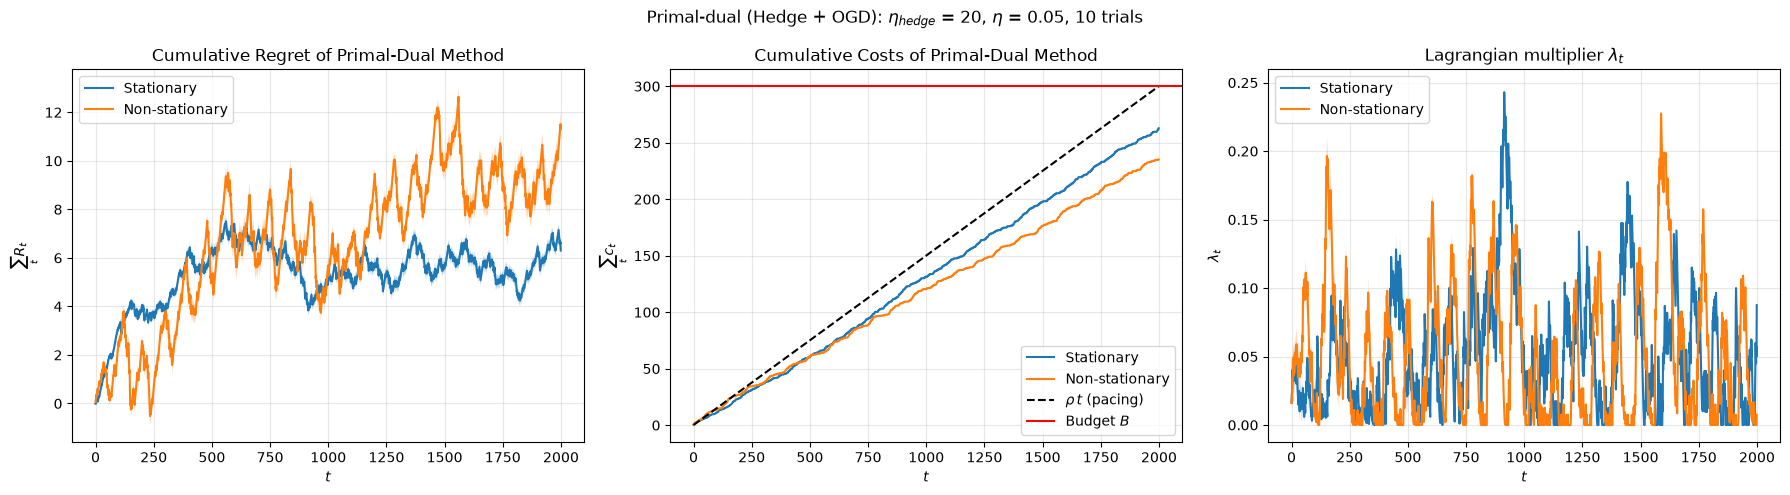

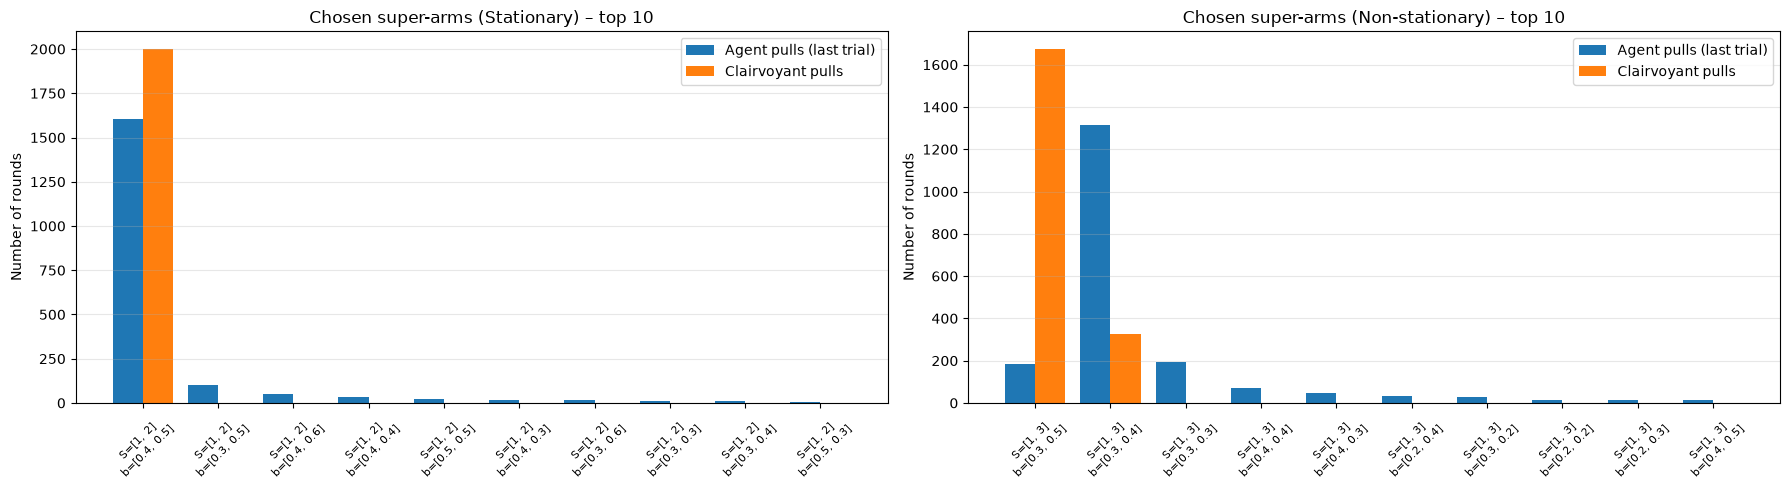

In [35]:
## Plots: regret, cumulative cost, lambda, chosen super-arms

rounds = np.arange(T)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- cumulative regret ---
for name, r in results.items():
    mean, std = r["regret"].mean(axis=0), r["regret"].std(axis=0)
    axes[0].plot(rounds, mean, label=name)
    axes[0].fill_between(rounds,
                         mean - std / np.sqrt(n_trials),
                         mean + std / np.sqrt(n_trials),
                         alpha=0.3)
axes[0].set_title("Cumulative Regret of Primal-Dual Method")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("$\\sum_t R_t$")

# --- cumulative cost ---
for name, r in results.items():
    mean, std = r["costs"].mean(axis=0), r["costs"].std(axis=0)
    axes[1].plot(rounds, mean, label=name)
    axes[1].fill_between(rounds,
                         mean - std / np.sqrt(n_trials),
                         mean + std / np.sqrt(n_trials),
                         alpha=0.3)
axes[1].plot(rounds, rho * (rounds + 1), "k--", label="$\\rho\\, t$ (pacing)")
axes[1].axhline(B, color="red", label="Budget $B$")
axes[1].set_title("Cumulative Costs of Primal-Dual Method")
axes[1].set_xlabel("$t$")
axes[1].set_ylabel("$\\sum_t c_t$")

# --- Lagrangian multiplier ---
for name, r in results.items():
    mean, std = r["lmbds"].mean(axis=0), r["lmbds"].std(axis=0)
    axes[2].plot(rounds, mean, label=name)
    axes[2].fill_between(rounds,
                         mean - std / np.sqrt(n_trials),
                         mean + std / np.sqrt(n_trials),
                         alpha=0.3)
axes[2].set_title("Lagrangian multiplier $\\lambda_t$")
axes[2].set_xlabel("$t$")
axes[2].set_ylabel("$\\lambda_t$")

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle(f"Primal-dual (Hedge + OGD): $\\eta_{{hedge}}$ = {hedge_eta}, $\\eta$ = {eta}, {n_trials} trials")
plt.tight_layout()
plt.show()

# --- chosen super-arms vs clairvoyant (top 10, since |A| is large) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, (name, r) in zip(axes, results.items()):
    clairvoyant = clairvoyant_stat if name == "Stationary" else clairvoyant_nonstat
    clairvoyant_pulls = clairvoyant.gamma * T

    top = np.argsort(-(r["N_pulls"] + clairvoyant_pulls))[:10]
    labels = [
        f"S={[c + 1 for c in super_arms[k][0]]}\nb={[round(float(b), 1) for b in super_arms[k][1]]}"
        for k in top
    ]
    x = np.arange(len(top))
    width = 0.4
    ax.bar(x - width / 2, r["N_pulls"][top], width=width, label="Agent pulls (last trial)")
    ax.bar(x + width / 2, clairvoyant_pulls[top], width=width, label="Clairvoyant pulls")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8, rotation=45)
    ax.set_title(f"Chosen super-arms ({name}) – top 10")
    ax.set_ylabel("Number of rounds")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Chosen super-arms vs clairvoyant.** On the stationary sequence the agent converges to exactly the clairvoyant super-arm ($S = \{1, 2\}$, $b = (0.4, 0.5)$), playing it in about $1600$ of the $2000$ rounds. On the non-stationary sequence the clairvoyant mixes $b_3 \in \{0.4, 0.5\}$ on $S = \{1, 3\}$, while the agent lands mostly on $b = (0.3, 0.4)$: the same campaigns with a slightly cheaper bid on campaign 3, which is what we expect since $\lambda_t > 0$ pushes the primal player toward the lower-cost option. In both cases the agent matches the fixed-strategy benchmark closely, hence the small regret. (DOUBLE CHECK)